# Compare Two BioDiscoveryAgent Runs

Compares two `sampled_genes_N.npy` output files (e.g. from two different models) against a dataset's ground-truth hit list, and plots the results.

Run this from the `BioDiscoveryAgent` repo root (or adjust the paths in the **Settings** cell below), so `datasets/` and `CEGv2.txt` resolve correctly.

**Steps:** edit the paths and labels in the Settings cell, then run all cells in order (Cell → Run All).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from matplotlib_venn import venn2
    HAVE_VENN = True
except ImportError:
    HAVE_VENN = False
    print("matplotlib_venn not installed -- the Venn diagram cell will show a "
          "text summary instead. Run `pip install matplotlib-venn` for a real "
          "Venn diagram, then re-run this cell.")

## 2. Settings

Edit these to point at your own files. `pred_a` and `pred_b` are the two `sampled_genes_N.npy` files you want to compare.

In [2]:
pred_a_path = "sonnet_IFNG/test/sampled_genes_5.npy"
pred_b_path = "haiku_IFNG_rerun2/test/sampled_genes_5.npy"
label_a = "Sonnet 4.6"
label_b = "Haiku 4.5"

dataset = "IFNG"                       # matches datasets/ground_truth_<dataset>.csv
essential_file = "CEGv2.txt"           # essential-genes list

## 3. Load data and compute hit ratios

In [3]:
def load_gene_set(path):
    arr = np.load(path, allow_pickle=True)
    return set(arr.tolist())


def compute_hit_ratios(pred_set, topmovers_set, essential_set):
    hits_all = pred_set & topmovers_set
    pred_ne = pred_set - essential_set
    topmovers_ne = topmovers_set - essential_set
    hits_ne = pred_ne & topmovers_ne
    return {
        "hits_all": len(hits_all),
        "total_all": len(topmovers_set),
        "ratio_all": len(hits_all) / len(topmovers_set),
        "hits_ne": len(hits_ne),
        "total_ne": len(topmovers_ne),
        "ratio_ne": len(hits_ne) / len(topmovers_ne),
    }


pred_a = load_gene_set(pred_a_path)
pred_b = load_gene_set(pred_b_path)

topmovers = set(np.load(f"datasets/topmovers_{dataset}.npy", allow_pickle=True).tolist())
essential = set(pd.read_csv(essential_file, delimiter="\t")["GENE"].tolist())

stats_a = compute_hit_ratios(pred_a, topmovers, essential)
stats_b = compute_hit_ratios(pred_b, topmovers, essential)

print(f"{label_a}: All hits = {stats_a['hits_all']}/{stats_a['total_all']} "
      f"({stats_a['ratio_all']:.4f})  |  N/E hits = {stats_a['hits_ne']}/{stats_a['total_ne']} "
      f"({stats_a['ratio_ne']:.4f})")
print(f"{label_b}: All hits = {stats_b['hits_all']}/{stats_b['total_all']} "
      f"({stats_b['ratio_all']:.4f})  |  N/E hits = {stats_b['hits_ne']}/{stats_b['total_ne']} "
      f"({stats_b['ratio_ne']:.4f})")

Sonnet 4.6: All hits = 88/920 (0.0957)  |  N/E hits = 86/802 (0.1072)
Haiku 4.5: All hits = 85/920 (0.0924)  |  N/E hits = 84/802 (0.1047)


## 4. Plot: hit ratio comparison (All genes vs. Non-essential)

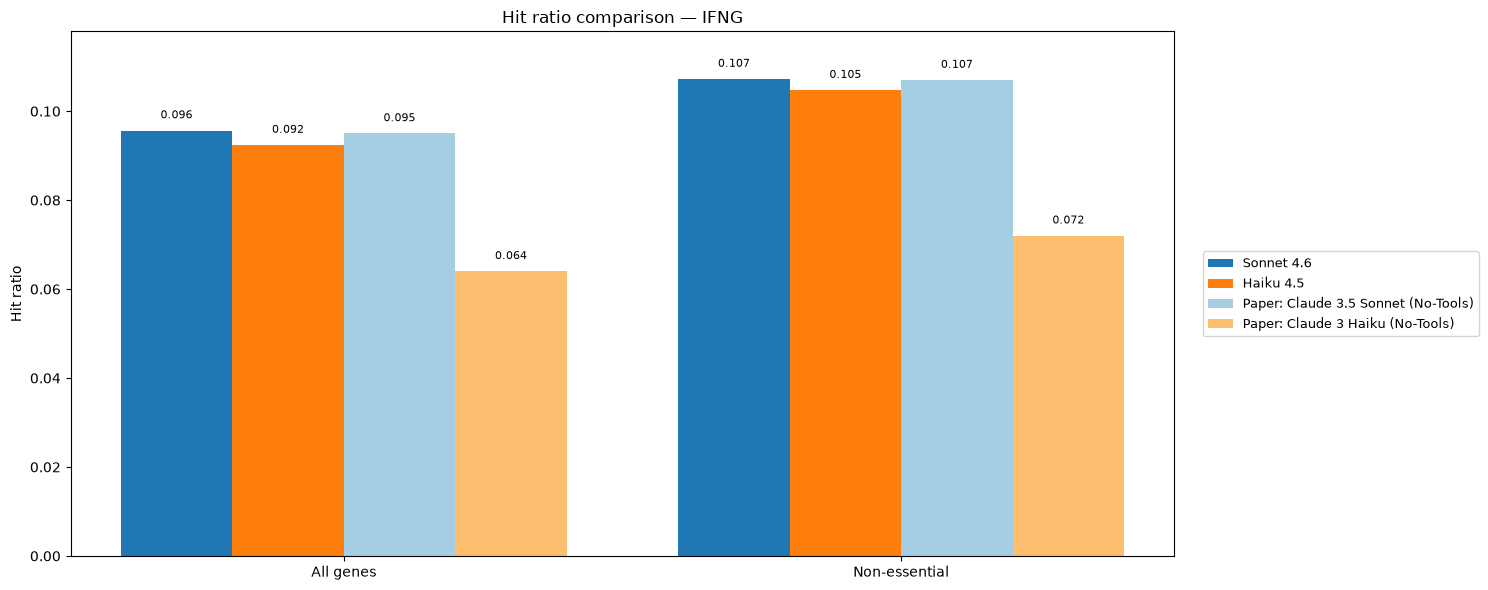

In [4]:
PAPER_REFERENCES = {
    # Table 1: Claude 3.5 Sonnet, No-Tools, round 5, All / Non-essential (N/E)
    "Paper: Claude 3.5 Sonnet (No-Tools)": {
        "IFNG": {"all": 0.095, "ne": 0.107},
        "IL2": {"all": 0.104, "ne": 0.122},
        "Carnevale22_Adenosine": {"all": 0.042, "ne": 0.044},
        "Scharenberg22": {"all": 0.326, "ne": 0.292},
        "Sanchez21_down": {"all": 0.066, "ne": 0.063},
        "Sanchez21": {"all": 0.066, "ne": 0.063},
    },
    # Table 1: Claude 3 Haiku, No-Tools, round 5, All / Non-essential (N/E)
    "Paper: Claude 3 Haiku (No-Tools)": {
        "IFNG": {"all": 0.064, "ne": 0.072},
        "IL2": {"all": 0.072, "ne": 0.083},
        "Carnevale22_Adenosine": {"all": 0.032, "ne": 0.034},
        "Scharenberg22": {"all": 0.209, "ne": 0.200},
        "Sanchez21_down": {"all": 0.056, "ne": 0.056},
        "Sanchez21": {"all": 0.056, "ne": 0.056},
    },
}

# Shades per model family: index 0 = your current run, index 1+ = paper references
# for that same family. Bars are matched to a family by checking the label text.
FAMILY_COLORS = {
    "sonnet": ["#1f77b4", "#a6cee3", "#4a90c4"],   # dark blue -> light blue
    "haiku":  ["#ff7f0e", "#fdbf6f", "#e8973f"],   # dark orange -> light orange
}
FALLBACK_COLORS = ["#808080", "#B0B0B0", "#404040"]

categories = ["All genes", "Non-essential"]
series = [(label_a, [stats_a["ratio_all"], stats_a["ratio_ne"]]),
          (label_b, [stats_b["ratio_all"], stats_b["ratio_ne"]])]

for ref_label, ref_data in PAPER_REFERENCES.items():
    if dataset in ref_data:
        series.append((ref_label, [ref_data[dataset]["all"], ref_data[dataset]["ne"]]))
    else:
        print(f"No paper reference stored for '{ref_label}' on dataset '{dataset}' -- skipping.")


def get_family(label):
    lower = label.lower()
    if "sonnet" in lower:
        return "sonnet"
    if "haiku" in lower:
        return "haiku"
    return None


family_counts = {"sonnet": 0, "haiku": 0}
fallback_idx = 0
colors = []
for label, _ in series:
    family = get_family(label)
    if family:
        idx = family_counts[family]
        palette = FAMILY_COLORS[family]
        colors.append(palette[idx % len(palette)])
        family_counts[family] += 1
    else:
        colors.append(FALLBACK_COLORS[fallback_idx % len(FALLBACK_COLORS)])
        fallback_idx += 1

n_bars = len(series)
width = 0.8 / n_bars
x = np.arange(len(categories))
offsets = [-0.4 + width / 2 + i * width for i in range(n_bars)]

fig, ax = plt.subplots(figsize=(15, 6))
all_vals = []
for (label, vals), offset, color in zip(series, offsets, colors):
    ax.bar(x + offset, vals, width, label=label, color=color)
    all_vals.extend(vals)

y_pad = max(all_vals) * 0.02
ax.set_ylim(0, max(all_vals) * 1.1)
for (label, vals), offset in zip(series, offsets):
    for i, v in enumerate(vals):
        ax.text(x[i] + offset, v + y_pad, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Hit ratio")
ax.set_title(f"Hit ratio comparison — {dataset}")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
fig.savefig("hit_ratio_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Plot: hit composition (shared vs. model-specific)

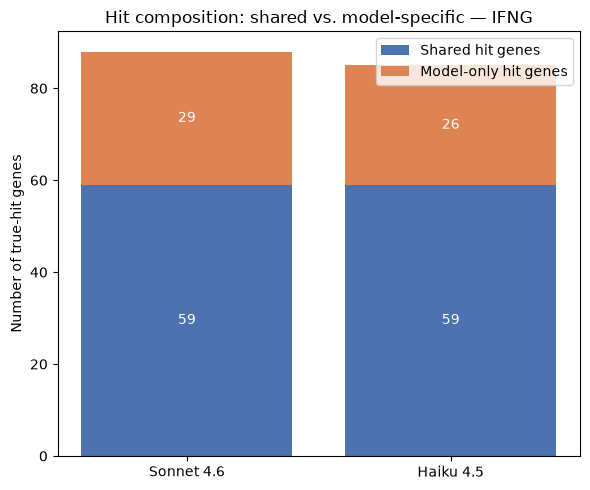

In [5]:
shared_hits = (pred_a & pred_b) & topmovers
a_only_hits = (pred_a - pred_b) & topmovers
b_only_hits = (pred_b - pred_a) & topmovers

fig, ax = plt.subplots(figsize=(6, 5))
labels = [label_a, label_b]
shared_vals = [len(shared_hits), len(shared_hits)]
unique_vals = [len(a_only_hits), len(b_only_hits)]

ax.bar(labels, shared_vals, label="Shared hit genes", color="#4C72B0")
ax.bar(labels, unique_vals, bottom=shared_vals, label="Model-only hit genes", color="#DD8452")

for i, (s, u) in enumerate(zip(shared_vals, unique_vals)):
    ax.text(i, s / 2, str(s), ha="center", va="center", color="white", fontsize=10)
    ax.text(i, s + u / 2, str(u), ha="center", va="center", color="white", fontsize=10)

ax.set_ylabel("Number of true-hit genes")
ax.set_title(f"Hit composition: shared vs. model-specific — {dataset}")
ax.legend()
fig.tight_layout()
fig.savefig("overlap_breakdown.png", dpi=150)
plt.show()

## 6. Plot: predicted gene set overlap (Venn diagram)

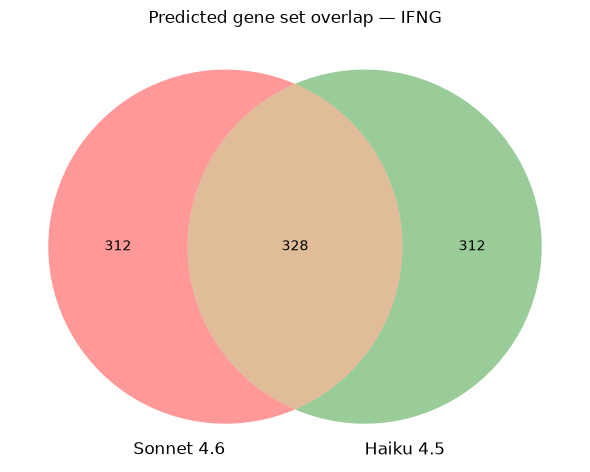

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
if HAVE_VENN:
    venn2([pred_a, pred_b], set_labels=(label_a, label_b), ax=ax)
    ax.set_title(f"Predicted gene set overlap — {dataset}")
else:
    ax.axis("off")
    overlap = len(pred_a & pred_b)
    ax.text(0.5, 0.6, f"{label_a} only: {len(pred_a - pred_b)}", ha="center", fontsize=12)
    ax.text(0.5, 0.5, f"Shared: {overlap}", ha="center", fontsize=12)
    ax.text(0.5, 0.4, f"{label_b} only: {len(pred_b - pred_a)}", ha="center", fontsize=12)
    ax.text(0.5, 0.25, "(install matplotlib-venn for a real Venn diagram:\npip install matplotlib-venn)",
            ha="center", fontsize=9, color="gray")
    ax.set_title(f"Predicted gene set overlap — {dataset}")
fig.tight_layout()
fig.savefig("gene_overlap_venn.png", dpi=150)
plt.show()

## 7. (Optional) Inspect the specific genes behind each model's unique hits

Useful for understanding *why* two models land on similar/different hit ratios -- e.g. checking whether they're drawing on the same biological themes even when picking different specific genes.

In [7]:
a_only_hit_genes = sorted((pred_a - pred_b) & topmovers)
b_only_hit_genes = sorted((pred_b - pred_a) & topmovers)

print(f"{label_a}-only hit genes ({len(a_only_hit_genes)}):")
print(a_only_hit_genes)
print()
print(f"{label_b}-only hit genes ({len(b_only_hit_genes)}):")
print(b_only_hit_genes)

Sonnet 4.6-only hit genes (29):
['CD2', 'CD27', 'CD3D', 'CD5', 'CD6', 'CHD7', 'CUL3', 'DNTTIP1', 'DUSP10', 'DYRK1A', 'EIF4EBP1', 'HMGB1', 'IKBKB', 'KAT7', 'MAP2K7', 'NCKAP1L', 'NSD2', 'PRKAB2', 'PRMT1', 'PRMT5', 'RBCK1', 'RBPJ', 'RHOA', 'RHOG', 'SH2D1A', 'SHARPIN', 'SHOC2', 'TRADD', 'TRIM8']

Haiku 4.5-only hit genes (26):
['AHR', 'BRD9', 'CCL22', 'CDKN1B', 'CISH', 'HDAC8', 'IL17A', 'ILF2', 'IRAK3', 'KMT2A', 'MFAP1', 'PIK3R4', 'PRDM4', 'PRKCH', 'RBBP5', 'RIPK1', 'RRAS2', 'RTEL1', 'S1PR1', 'SEH1L', 'SMC3', 'TNFRSF1A', 'TNFRSF1B', 'TNFRSF8', 'TRIM21', 'WDR59']


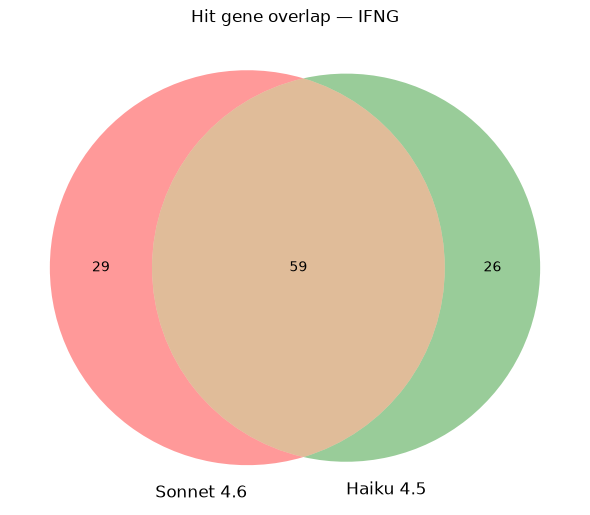

In [8]:
hits_a = pred_a & topmovers
hits_b = pred_b & topmovers

fig, ax = plt.subplots(figsize=(6, 6))
if HAVE_VENN:
    venn2([hits_a, hits_b], set_labels=(label_a, label_b), ax=ax)
    ax.set_title(f"Hit gene overlap — {dataset}")
else:
    ax.axis("off")
    overlap = len(hits_a & hits_b)
    ax.text(0.5, 0.6, f"{label_a}-only hits: {len(hits_a - hits_b)}", ha="center", fontsize=12)
    ax.text(0.5, 0.5, f"Shared hits: {overlap}", ha="center", fontsize=12)
    ax.text(0.5, 0.4, f"{label_b}-only hits: {len(hits_b - hits_a)}", ha="center", fontsize=12)
    ax.text(0.5, 0.25, "(install matplotlib-venn for a real Venn diagram:\npip install matplotlib-venn)",
            ha="center", fontsize=9, color="gray")
    ax.set_title(f"Hit gene overlap — {dataset}")
fig.tight_layout()
fig.savefig("hit_overlap_venn.png", dpi=150)
plt.show()

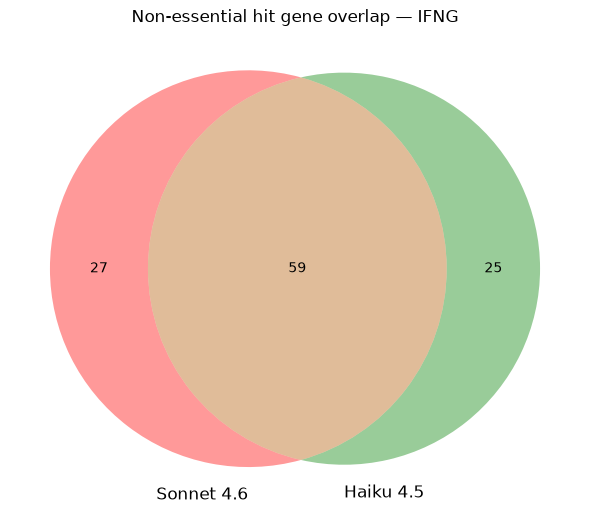

Sonnet 4.6 non-essential hits: 86
Haiku 4.5 non-essential hits: 84
Shared: 59
Sonnet 4.6-only: 27
Haiku 4.5-only: 25


In [9]:
topmovers_ne = topmovers - essential
hits_a_ne = (pred_a - essential) & topmovers_ne
hits_b_ne = (pred_b - essential) & topmovers_ne

fig, ax = plt.subplots(figsize=(6, 6))
if HAVE_VENN:
    venn2([hits_a_ne, hits_b_ne], set_labels=(label_a, label_b), ax=ax)
    ax.set_title(f"Non-essential hit gene overlap — {dataset}")
else:
    ax.axis("off")
    overlap = len(hits_a_ne & hits_b_ne)
    ax.text(0.5, 0.6, f"{label_a}-only hits: {len(hits_a_ne - hits_b_ne)}", ha="center", fontsize=12)
    ax.text(0.5, 0.5, f"Shared hits: {overlap}", ha="center", fontsize=12)
    ax.text(0.5, 0.4, f"{label_b}-only hits: {len(hits_b_ne - hits_a_ne)}", ha="center", fontsize=12)
    ax.text(0.5, 0.25, "(install matplotlib-venn for a real Venn diagram:\npip install matplotlib-venn)",
            ha="center", fontsize=9, color="gray")
    ax.set_title(f"Non-essential hit gene overlap — {dataset}")
fig.tight_layout()
fig.savefig("hit_overlap_venn_nonessential.png", dpi=150)
plt.show()

print(f"{label_a} non-essential hits: {len(hits_a_ne)}")
print(f"{label_b} non-essential hits: {len(hits_b_ne)}")
print(f"Shared: {len(hits_a_ne & hits_b_ne)}")
print(f"{label_a}-only: {len(hits_a_ne - hits_b_ne)}")
print(f"{label_b}-only: {len(hits_b_ne - hits_a_ne)}")